# Эксперимент 03: VGGish + ML (SVM)

**Статья:** CNN Architectures for Large-Scale Audio Classification (Архитектуры CNN для крупномасштабной аудиоклассификации) 2016

**Ссылка:** [https://arxiv.org/abs/1609.09430](https://arxiv.org/abs/1609.09430)

**Краткое описание модели:** Предобученные VGGish-эмбеддинги на уровне аудиофайла (агрегация по времени) -> SVM-классификатор.

**Содержание статьи:** Работы по AudioSet/VGGish показывают переносимость универсальных аудиоэмбеддингов на новые задачи. Вместо ручной инженерии признаков модель использует уже выученные представления из крупного корпуса. Это позволяет проверить, насколько общие акустические признаки полезны для детекции речевых дефектов.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
import torch
import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    precision_score,
    recall_score,
    classification_report,
)
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
from shared import config, data_utils
from shared.results_utils import save_result_csv

## 1. Загрузка VGGish и разбиений

In [ ]:
vggish = torch.hub.load("harritaylor/torchvggish", "vggish")
vggish.eval()

paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

Using cache found in /home/dk/.cache/torch/hub/harritaylor_torchvggish_master


Train: 1942, Val: 417, Test: 417


## 2. Извлечение эмбеддингов VGGish (агрегация по файлу)

In [3]:
def extract_vggish_aggregated(path):
    """Один файл → эмбеддинги (T, 128) → mean и std по времени → вектор 256."""
    with torch.no_grad():
        emb = vggish.forward(path)
    emb = emb.cpu().numpy()
    if emb.ndim == 1:
        emb = emb.reshape(1, -1)
    mean_ = emb.mean(axis=0).astype(np.float32)
    std_  = emb.std(axis=0).astype(np.float32)
    std_  = np.where(std_ < 1e-8, 1.0, std_)
    return np.concatenate([mean_, std_])

def build_vggish_matrix(paths, letters=None, n_jobs=-1):
    rows = []
    for p in tqdm.tqdm(paths, desc="VGGish"):
        row = extract_vggish_aggregated(p)
        rows.append(row)
    X = np.stack(rows)
    if letters is not None and letters.shape[1] > 0:
        X = np.hstack([X, letters.astype(np.float32)])
    return X

print("Train...")
X_train = build_vggish_matrix(paths_train, letters_train)
print("Val...")
X_val   = build_vggish_matrix(paths_val, letters_val)
print("Test...")
X_test  = build_vggish_matrix(paths_test, letters_test)
print(f"Признаков на объект: {X_train.shape[1]}")

Train...


VGGish: 100%|██████████| 1942/1942 [04:48<00:00,  6.73it/s]


Val...


VGGish: 100%|██████████| 417/417 [01:15<00:00,  5.52it/s]


Test...


VGGish: 100%|██████████| 417/417 [01:04<00:00,  6.46it/s]

Признаков на объект: 264


## 3. Масштабирование, подбор гиперпараметров и обучение SVM

Гиперпараметры подбираются по обучающей выборке (GridSearchCV, 5-fold CV, метрика F1-macro), как в эксперименте 01. Пайплайн: StandardScaler → SVC.

In [4]:
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", class_weight=class_weight, random_state=config.RANDOM_STATE)),
])

param_grid = {
    "clf__C": [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.05, 0.1, 0.5],
}

grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="f1_macro",
    refit=True,
    n_jobs=-1,
    verbose=1,
)
t0 = time.perf_counter()
grid.fit(X_train, y_train)
train_time_sec = time.perf_counter() - t0

print("Лучшие гиперпараметры (по F1-macro на CV):", grid.best_params_)
print("Лучший F1-macro (CV):", f"{grid.best_score_:.4f}")

clf = grid.best_estimator_
y_pred = clf.predict(X_test)
y_proba = clf.decision_function(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")
print(f"Precision (bad): {precision_bad:.4f}")
print(f"Recall (bad):    {recall_bad:.4f}")

Fitting 5 folds for each of 49 candidates, totalling 245 fits


Лучшие гиперпараметры (по F1-macro на CV): {'clf__C': 1.0, 'clf__gamma': 'scale'}
Лучший F1-macro (CV): 0.6921
              precision    recall  f1-score   support

        good       0.81      0.76      0.79       282
         bad       0.56      0.64      0.60       135

    accuracy                           0.72       417
   macro avg       0.69      0.70      0.69       417
weighted avg       0.73      0.72      0.73       417

Accuracy: 0.7218
F1 macro: 0.6924
F1 (bad): 0.5972
ROC-AUC:  0.7890
Precision (bad): 0.5621
Recall (bad):    0.6370


### Графики: зависимость F1-macro (CV) от гиперпараметров

По оси X — значение гиперпараметра, по оси Y — средний F1-macro по 5-fold CV.

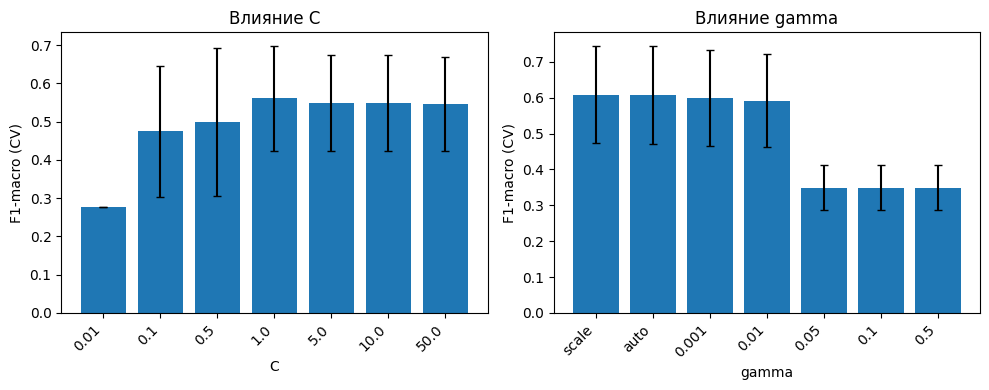

In [5]:
cv_results = grid.cv_results_
param_names = list(param_grid.keys())

fig, axes = plt.subplots(1, len(param_names), figsize=(5 * len(param_names), 4))
if len(param_names) == 1:
    axes = [axes]
for ax, pname in zip(axes, param_names):
    key = "param_" + pname
    vals = list(param_grid[pname])
    scores_mean = []
    scores_std = []
    for v in vals:
        mask = cv_results[key] == v
        scores_mean.append(np.mean(cv_results["mean_test_score"][mask]))
        s = np.std(cv_results["mean_test_score"][mask])
        scores_std.append(s if not np.isnan(s) else 0.0)
    x = np.arange(len(vals))
    ax.bar(x, scores_mean, yerr=scores_std, capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([str(v) for v in vals], rotation=45, ha="right")
    ax.set_xlabel(pname.replace("clf__", ""))
    ax.set_ylabel("F1-macro (CV)")
    ax.set_title(f"Влияние {pname.replace('clf__', '')}")
plt.tight_layout()
plt.show()

## 4. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_03_vggish_ml",
    experiment_name="VGGish + SVM",
    model="VGGish (agg) + SVC (RBF)",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="VGGish mean+std per file (256 dim), GridSearchCV " + str(grid.best_params_),
    num_params=None,
    train_time_sec=train_time_sec,
)